# Exercise 6.1



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

### Exact solutions

In [30]:
points=30
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )


heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)


h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)


X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)




In [39]:
cvs_gb=pd.read_csv('OUTPUT/gibbs/specific_heat_T.dat', delimiter=r"\s+")
Ma_gb=pd.read_csv('OUTPUT/gibbs/magnetization_T.dat', delimiter=r"\s+")
TE_gb=pd.read_csv('OUTPUT/gibbs/total_energy_T.dat', delimiter=r"\s+")
Xs_gb=pd.read_csv('OUTPUT/gibbs/susceptibility_T.dat', delimiter=r"\s+")

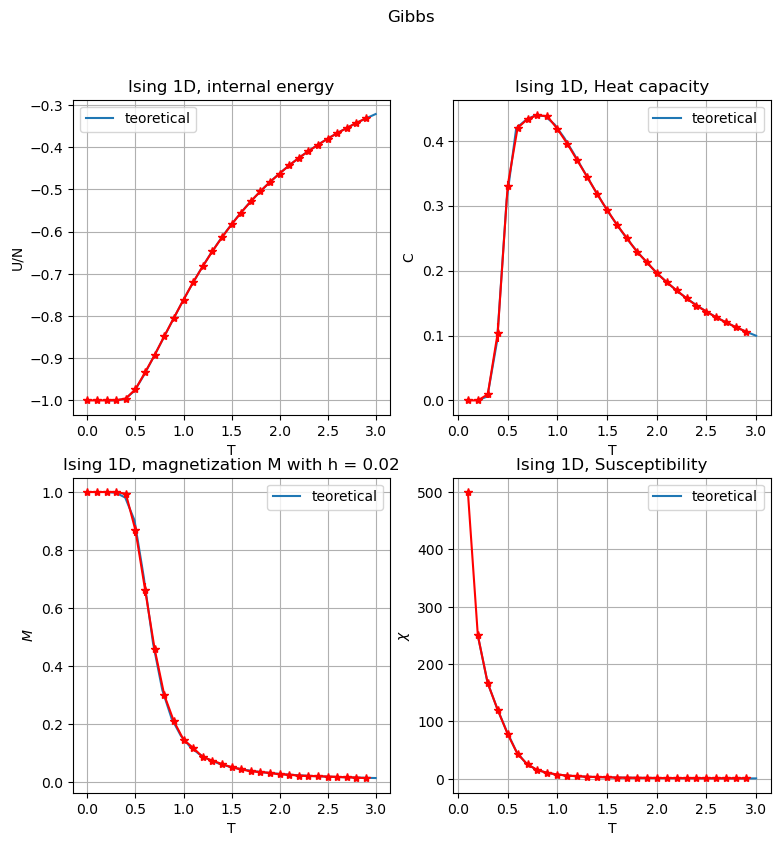

In [40]:
fig, ax = plt.subplots(2, 2, figsize=(9,9))
fig.suptitle('Gibbs')
ax[0,0].plot(T, e, label='teoretical')
ax[0,0].errorbar(TE_gb.TEMP, TE_gb.TE_AVE, yerr=TE_gb.ERROR, c='r', marker='*')

ax[0,0].set_title('Ising 1D, internal energy')
ax[0,0].set_xlabel('T')
ax[0,0].set_ylabel('U/N')

ax[0,1].plot(T, heat, label='teoretical')
ax[0,1].errorbar(cvs_gb.TEMP, cvs_gb.CV_AVE, yerr=cvs_gb.ERROR, c='r', marker='*')
ax[0,1].set_title('Ising 1D, Heat capacity')
ax[0,1].set_xlabel('T')
ax[0,1].set_ylabel('C')

ax[1,0].plot(T, M, label='teoretical')
ax[1,0].errorbar(Ma_gb.TEMP, Ma_gb.M_AVE, yerr=Ma_gb.ERROR, c='r', marker='*')
ax[1,0].set_title('Ising 1D, magnetization M with h = 0.02')
ax[1,0].set_xlabel('T')
ax[1,0].set_ylabel(r'$M$')

ax[1,1].plot(T, X, label='teoretical')
ax[1,1].errorbar(Xs_gb.TEMP, Xs_gb.X_AVE, Xs_gb.ERROR, c='r', marker='*')
ax[1,1].set_title('Ising 1D, Susceptibility')
ax[1,1].set_xlabel('T')
ax[1,1].set_ylabel(r'$\chi$')

for k in [0,1]:
    for j in [0,1]:
        ax[k,j].legend()
        ax[k,j].grid()
plt.show()

In [44]:
cvs_mc=pd.read_csv('OUTPUT/MRT2/specific_heat_T.dat', delimiter=r"\s+")
Ma_mc=pd.read_csv('OUTPUT/MRT2/magnetization_T.dat', delimiter=r"\s+")
TE_mc=pd.read_csv('OUTPUT/MRT2/total_energy_T.dat', delimiter=r"\s+")
Xs_mc=pd.read_csv('OUTPUT/MRT2/susceptibility_T.dat', delimiter=r"\s+")

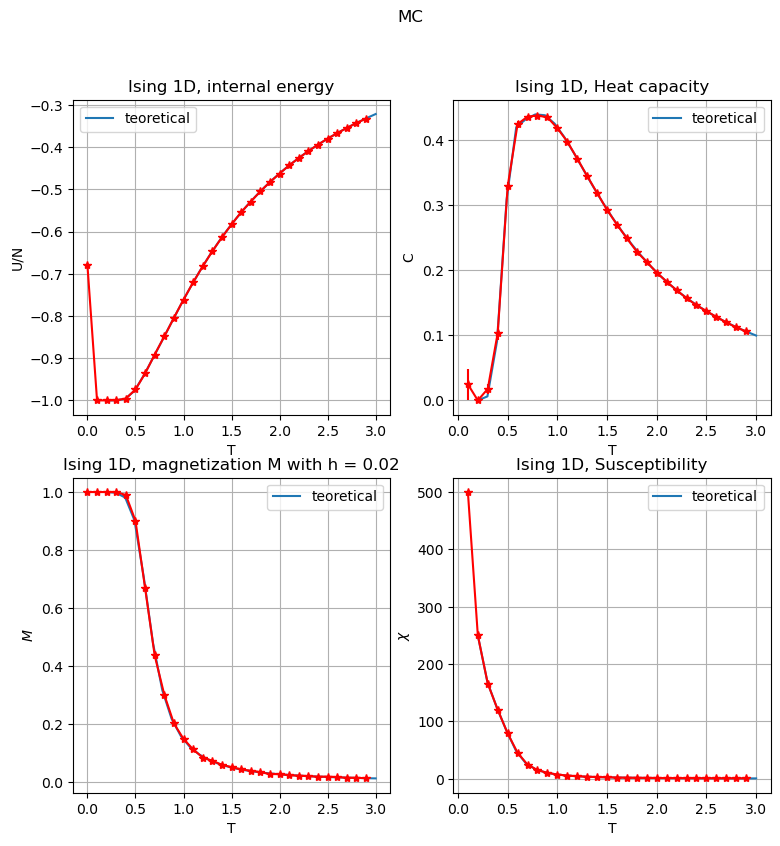

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(9,9))
fig.suptitle('MC')
ax[0,0].plot(T, e, label='teoretical')
ax[0,0].errorbar(TE_mc.TEMP, TE_mc.TE_AVE, yerr=TE_mc.ERROR, c='r', marker='*')

ax[0,0].set_title('Ising 1D, internal energy')
ax[0,0].set_xlabel('T')
ax[0,0].set_ylabel('U/N')

ax[0,1].plot(T, heat, label='teoretical')
ax[0,1].errorbar(cvs_mc.TEMP, cvs_mc.CV_AVE, yerr=cvs_mc.ERROR, c='r', marker='*')
ax[0,1].set_title('Ising 1D, Heat capacity')
ax[0,1].set_xlabel('T')
ax[0,1].set_ylabel('C')

ax[1,0].plot(T, M, label='teoretical')
ax[1,0].errorbar(Ma_mc.TEMP, Ma_mc.M_AVE, yerr=Ma_mc.ERROR, c='r', marker='*')
ax[1,0].set_title('Ising 1D, magnetization M with h = 0.02')
ax[1,0].set_xlabel('T')
ax[1,0].set_ylabel(r'$M$')

ax[1,1].plot(T, X, label='teoretical')
ax[1,1].errorbar(Xs_mc.TEMP, Xs_mc.X_AVE, Xs_mc.ERROR, c='r', marker='*')
ax[1,1].set_title('Ising 1D, Susceptibility')
ax[1,1].set_xlabel('T')
ax[1,1].set_ylabel(r'$\chi$')

for k in [0,1]:
    for j in [0,1]:
        ax[k,j].legend()
        ax[k,j].grid()
plt.show()

## Plotting both

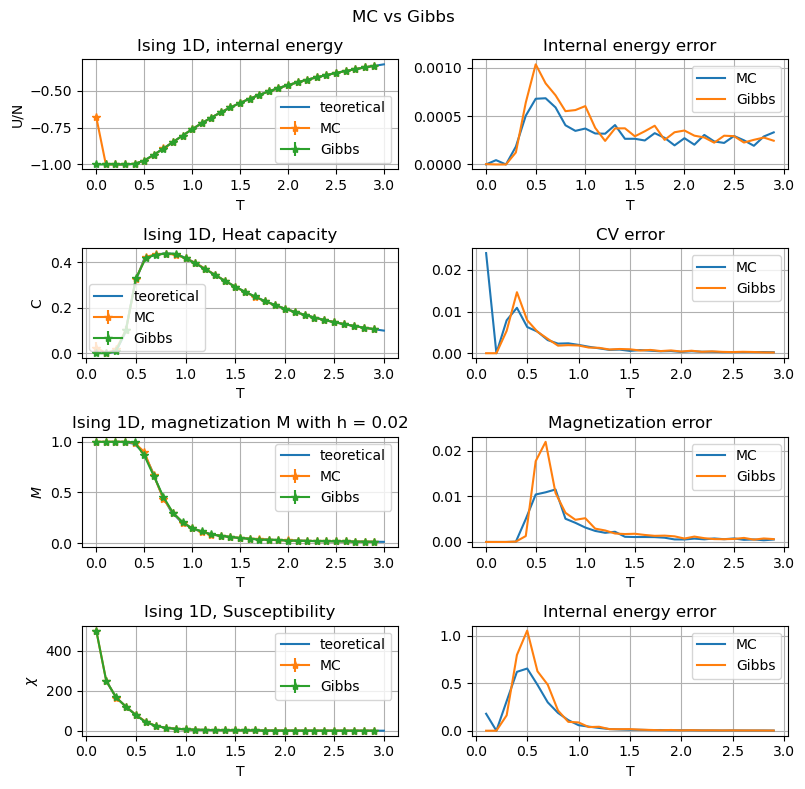

In [77]:
fig, ax = plt.subplots(4, 2, figsize=(8,8))
fig.suptitle('MC vs Gibbs')
ax[0,0].plot(T, e, label='teoretical')
ax[0,0].errorbar(TE_mc.TEMP, TE_mc.TE_AVE, yerr=TE_mc.ERROR, marker='*', label='MC')
ax[0,0].errorbar(TE_gb.TEMP, TE_gb.TE_AVE, yerr=TE_gb.ERROR, marker='*', label='Gibbs')

ax[0,0].set_title('Ising 1D, internal energy')
ax[0,0].set_xlabel('T')
ax[0,0].set_ylabel('U/N')

ax[0,1].set_title('Internal energy error')
ax[0,1].plot(TE_mc.TEMP, TE_mc.ERROR, label='MC')
ax[0,1].plot(TE_gb.TEMP, TE_gb.ERROR, label='Gibbs')
ax[0,1].set_xlabel('T')


ax[1,0].plot(T, heat, label='teoretical')
ax[1,0].errorbar(cvs_mc.TEMP, cvs_mc.CV_AVE, yerr=cvs_mc.ERROR, marker='*', label='MC')
ax[1,0].errorbar(cvs_gb.TEMP, cvs_gb.CV_AVE, yerr=cvs_gb.ERROR, marker='*', label='Gibbs')
ax[1,0].set_title('Ising 1D, Heat capacity')
ax[1,0].set_xlabel('T')
ax[1,0].set_ylabel('C')

ax[1,1].set_title('CV error')
ax[1,1].plot(cvs_mc.TEMP, cvs_mc.ERROR, label='MC')
ax[1,1].plot(cvs_gb.TEMP, cvs_gb.ERROR, label='Gibbs')
ax[1,1].set_xlabel('T')


ax[2,0].plot(T, M, label='teoretical')
ax[2,0].errorbar(Ma_mc.TEMP, Ma_mc.M_AVE, yerr=Ma_mc.ERROR, marker='*', label='MC')
ax[2,0].errorbar(Ma_gb.TEMP, Ma_gb.M_AVE, yerr=Ma_gb.ERROR, marker='*', label='Gibbs')
ax[2,0].set_title('Ising 1D, magnetization M with h = 0.02')
ax[2,0].set_xlabel('T')
ax[2,0].set_ylabel(r'$M$')

ax[2,1].set_title('Magnetization error')
ax[2,1].plot(Ma_mc.TEMP, Ma_mc.ERROR, label='MC')
ax[2,1].plot(Ma_gb.TEMP, Ma_gb.ERROR, label='Gibbs')
ax[2,1].set_xlabel('T')


ax[3,0].plot(T, X, label='teoretical')
ax[3,0].errorbar(Xs_mc.TEMP, Xs_mc.X_AVE, Xs_mc.ERROR, marker='*', label='MC')
ax[3,0].errorbar(Xs_gb.TEMP, Xs_gb.X_AVE, Xs_gb.ERROR, marker='*', label='Gibbs')
ax[3,0].set_title('Ising 1D, Susceptibility')
ax[3,0].set_xlabel('T')
ax[3,0].set_ylabel(r'$\chi$')

ax[3,1].set_title('Internal energy error')
ax[3,1].plot(Xs_mc.TEMP, Xs_mc.ERROR, label='MC')
ax[3,1].plot(Xs_gb.TEMP, Xs_gb.ERROR, label='Gibbs')
ax[3,1].set_xlabel('T')

for k in range(4):
    for j in [0,1]:
        ax[k,j].legend()
        ax[k,j].grid()
plt.tight_layout()
plt.show()

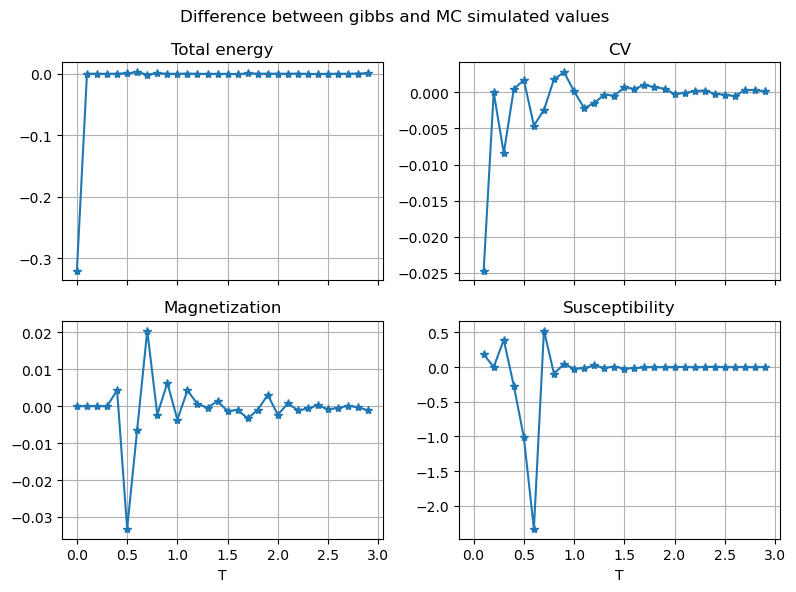

In [69]:

fig, ax = plt.subplots(2, 2, figsize=(8,6), sharex=True)#, sharey=True)
fig.suptitle('Difference between gibbs and MC simulated values')

ax[0,0].set_title('Total energy')
ax[0,0].plot(TE_gb.TEMP, TE_gb.TE_AVE-TE_mc.TE_AVE, '-*',label='')

ax[0,1].set_title('CV')
ax[0,1].plot(cvs_gb.TEMP, cvs_gb.CV_AVE-cvs_mc.CV_AVE, '-*', label='CV')

ax[1,0].set_title('Magnetization')
ax[1,0].plot(Ma_gb.TEMP, Ma_gb.M_AVE-Ma_mc.M_AVE, '-*',label='')

ax[1,1].set_title('Susceptibility')
ax[1,1].plot(Xs_gb.TEMP, Xs_gb.X_AVE-Xs_mc.X_AVE, '-*',label='')
for k in [0,1]:
    for j in [0,1]:
        ax[k,j].grid()
        ax[1,j].set_xlabel('T')
        
plt.tight_layout()
plt.show()

In [88]:
cvs=pd.read_csv('OUTPUT/specific_heat_T.dat', delimiter=r"\s+")
Ma=pd.read_csv('OUTPUT/magnetization_T.dat', delimiter=r"\s+")
TE=pd.read_csv('OUTPUT/total_energy_T.dat', delimiter=r"\s+")
Xs=pd.read_csv('OUTPUT/susceptibility_T.dat', delimiter=r"\s+")

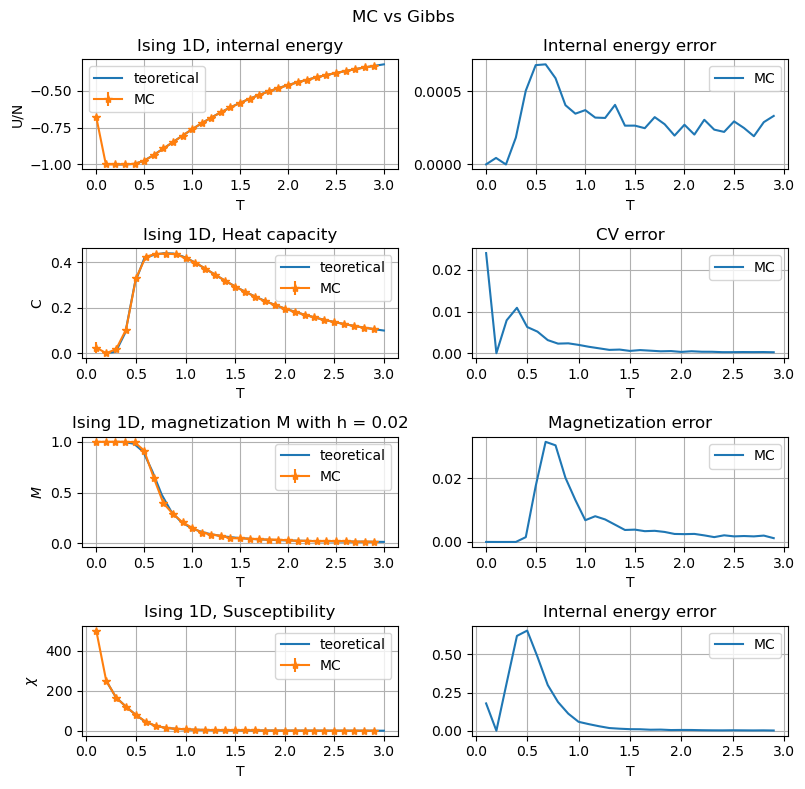

In [89]:
fig, ax = plt.subplots(4, 2, figsize=(8,8))
fig.suptitle('MC vs Gibbs')
ax[0,0].plot(T, e, label='teoretical')
ax[0,0].errorbar(TE.TEMP, TE.TE_AVE, yerr=TE.ERROR, marker='*', label='MC')

ax[0,0].set_title('Ising 1D, internal energy')
ax[0,0].set_xlabel('T')
ax[0,0].set_ylabel('U/N')

ax[0,1].set_title('Internal energy error')
ax[0,1].plot(TE.TEMP, TE.ERROR, label='MC')
ax[0,1].set_xlabel('T')


ax[1,0].plot(T, heat, label='teoretical')
ax[1,0].errorbar(cvs.TEMP, cvs.CV_AVE, yerr=cvs.ERROR, marker='*', label='MC')
ax[1,0].set_title('Ising 1D, Heat capacity')
ax[1,0].set_xlabel('T')
ax[1,0].set_ylabel('C')

ax[1,1].set_title('CV error')
ax[1,1].plot(cvs.TEMP, cvs.ERROR, label='MC')
ax[1,1].set_xlabel('T')


ax[2,0].plot(T, M, label='teoretical')
ax[2,0].errorbar(Ma.TEMP, Ma.M_AVE, yerr=Ma.ERROR, marker='*', label='MC')
ax[2,0].set_title('Ising 1D, magnetization M with h = 0.02')
ax[2,0].set_xlabel('T')
ax[2,0].set_ylabel(r'$M$')

ax[2,1].set_title('Magnetization error')
ax[2,1].plot(Ma.TEMP, Ma.ERROR, label='MC')
ax[2,1].set_xlabel('T')


ax[3,0].plot(T, X, label='teoretical')
ax[3,0].errorbar(Xs.TEMP, Xs.X_AVE, Xs.ERROR, marker='*', label='MC')
ax[3,0].set_title('Ising 1D, Susceptibility')
ax[3,0].set_xlabel('T')
ax[3,0].set_ylabel(r'$\chi$')

ax[3,1].set_title('Internal energy error')
ax[3,1].plot(Xs.TEMP, Xs.ERROR, label='MC')
ax[3,1].set_xlabel('T')

for k in range(4):
    for j in [0,1]:
        ax[k,j].legend()
        ax[k,j].grid()
plt.tight_layout()
plt.show()